In [1]:
## import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Load the dataset 
orders = pd.read_csv("master_dataset.csv")

In [3]:
## convert date columns to datetime format
orders["order_placement_date"] = pd.to_datetime(
    orders["order_placement_date"]
)

orders["agreed_delivery_date"] = pd.to_datetime(
    orders["agreed_delivery_date"]
)

orders["actual_delivery_date"] = pd.to_datetime(
    orders["actual_delivery_date"]
)

In [4]:
## Verify the data types of the columns
orders.head()

,order_id,order_placement_date,customer_id,product_id,order_qty,agreed_delivery_date,actual_delivery_date,delivery_qty,In Full,On Time,...,product_name,category,price_INR,price_USD,on_time,in_full,otif,ontime_target%,infull_target%,otif_target%
0,FMR34203601,2025-03-01,789203,25891601,110,2025-03-04,2025-03-04,110,1,1,...,AM Tea 500,beverages,225,6.0,1,1,1,92,76,70
1,FMR32320302,2025-03-01,789320,25891203,347,2025-03-02,2025-03-02,347,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,91,81,74
2,FMR33320501,2025-03-01,789320,25891203,187,2025-03-03,2025-03-03,150,0,1,...,AM Butter 500,Dairy,300,9.0,1,0,0,91,81,74
3,FMR34220601,2025-03-01,789220,25891203,235,2025-03-04,2025-03-04,235,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,91,76,69
4,FMR33703603,2025-03-01,789703,25891203,176,2025-03-03,2025-03-03,176,1,1,...,AM Butter 500,Dairy,300,9.0,1,1,1,85,78,66


In [5]:
## verify the dataset 
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 24195 entries, 0 to 24194
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_id              24195 non-null  str           
 1   order_placement_date  24195 non-null  datetime64[us]
 2   customer_id           24195 non-null  int64         
 3   product_id            24195 non-null  int64         
 4   order_qty             24195 non-null  int64         
 5   agreed_delivery_date  24195 non-null  datetime64[us]
 6   actual_delivery_date  24195 non-null  datetime64[us]
 7   delivery_qty          24195 non-null  int64         
 8   In Full               24195 non-null  int64         
 9   On Time               24195 non-null  int64         
 10  On Time In Full       24195 non-null  int64         
 11  customer_name         24195 non-null  str           
 12  city                  24195 non-null  str           
 13  currency              24195

In [6]:
# Create Date Features

orders["Month"] = orders["order_placement_date"].dt.month_name()

orders["Month_Number"] = orders["order_placement_date"].dt.month

orders["Year"] = orders["order_placement_date"].dt.year

orders["Quarter"] = orders["order_placement_date"].dt.quarter

orders["Weekday"] = orders["order_placement_date"].dt.day_name()

# KPI Analysis

## Project Objective

This notebook evaluates the company's operational performance using key supply chain metrics.

The analysis focuses on:

- On-Time Delivery (OT)
- In-Full Delivery (IF)
- On-Time In-Full (OTIF)
- Customer Performance
- City Performance
- Product Category Performance

The objective is to identify performance gaps, evaluate service levels, and generate business recommendations for improving supply chain efficiency.

# Business Question 3: City-wise Delivery Performance

This analysis evaluates delivery performance across different cities.

By comparing On-Time Delivery (OT), In-Full Delivery (IF), and OTIF across locations, we can identify operational strengths and weaknesses in the supply chain network.

The findings help management identify cities that require operational improvements and resource allocation to improve customer service.

In [7]:
city_delivery = (
    orders[
        [
            "city",
            "order_id",
            "on_time",
            "in_full",
            "otif"
        ]
    ]
    .drop_duplicates()
)

city_delivery.head()

,city,order_id,on_time,in_full,otif
0,Vadodara,FMR34203601,1,1,1
1,"New Jersey, US",FMR32320302,1,1,1
2,"New Jersey, US",FMR33320501,1,0,0
3,"New Jersey, US",FMR34220601,1,1,1
4,Vadodara,FMR33703603,1,1,1


In [8]:
city_performance = (
    city_delivery
    .groupby("city")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

city_performance["on_time"] *= 100
city_performance["in_full"] *= 100
city_performance["otif"] *= 100

city_performance = city_performance.round(2)

city_performance

,city,on_time,in_full,otif
0,Ahmedabad,58.54,54.06,29.27
1,"New Jersey, US",61.18,51.76,29.14
2,Vadodara,58.16,51.74,27.75


In [9]:
city_performance.sort_values(
    by="otif",
    ascending=False
)

,city,on_time,in_full,otif
0,Ahmedabad,58.54,54.06,29.27
1,"New Jersey, US",61.18,51.76,29.14
2,Vadodara,58.16,51.74,27.75


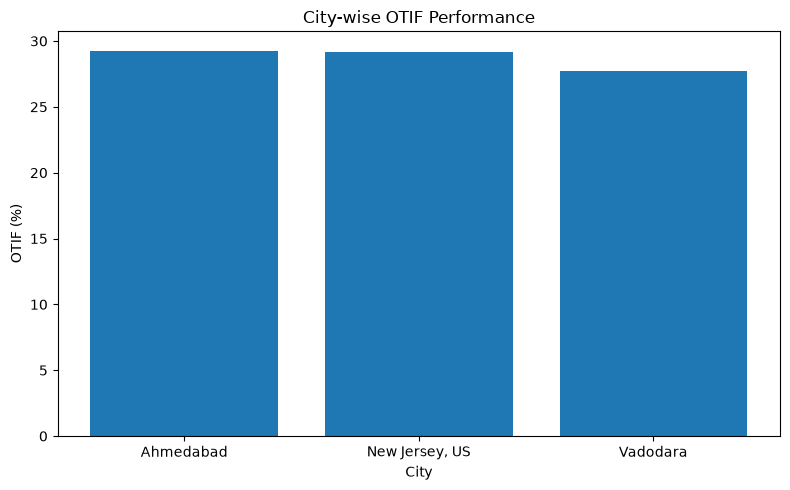

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    city_performance["city"],
    city_performance["otif"]
)

plt.title("City-wise OTIF Performance")
plt.xlabel("City")
plt.ylabel("OTIF (%)")

plt.tight_layout()

plt.show()

## Business Insights

### Key Findings

- **Ahmedabad** recorded the highest OTIF performance (**29.27%**), indicating relatively better coordination between inventory availability and delivery operations compared to the other cities.

- **New Jersey, US** achieved the highest On-Time Delivery rate (**61.18%**), suggesting efficient transportation and scheduling. However, its In-Full Delivery rate (**51.76%**) limited its overall OTIF performance.

- **Vadodara** showed the lowest OTIF performance (**27.75%**), indicating opportunities to improve inventory planning, warehouse fulfillment, and transportation coordination.

- Although performance differs across cities, the OTIF values remain below **30%** in all locations. This suggests that delivery challenges are not limited to a single city but exist across the overall supply chain network.

### Conclusion

The analysis indicates that all operating locations have room for improvement in meeting customer delivery expectations. Management should investigate the operational practices of higher-performing cities and apply those best practices to lower-performing locations. Improving inventory availability and delivery coordination across all cities can significantly increase OTIF performance and customer satisfaction.

Ahmedabad had the highest OTIF performance at 29.27%, while Vadodara recorded the lowest at 27.75%. New Jersey achieved the highest On-Time Delivery but still had a relatively low OTIF due to lower In-Full performance. Since OTIF is below 30% across all cities, the analysis suggests that delivery issues are organization-wide rather than city-specific. The company should improve inventory management and coordination between warehouses and transportation to increase overall delivery reliability

# Business Question 4: Product Category-wise Delivery Performance

This analysis evaluates delivery performance for each product category using three key supply chain metrics:

- On-Time Delivery (OT)
- In-Full Delivery (IF)
- On-Time In-Full (OTIF)

Comparing these KPIs across categories helps identify which product groups are easier to fulfill and which experience greater delivery challenges. These insights support inventory planning, warehouse operations, and transportation decisions.

In [11]:
category_delivery = (
    orders[
        [
            "category",
            "order_id",
            "on_time",
            "in_full",
            "otif"
        ]
    ]
    .drop_duplicates()
)

category_delivery.head()

,category,order_id,on_time,in_full,otif
0,beverages,FMR34203601,1,1,1
1,Dairy,FMR32320302,1,1,1
2,Dairy,FMR33320501,1,0,0
3,Dairy,FMR34220601,1,1,1
4,Dairy,FMR33703603,1,1,1


In [12]:
category_performance = (
    category_delivery
    .groupby("category")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

category_performance["on_time"] *= 100
category_performance["in_full"] *= 100
category_performance["otif"] *= 100

category_performance = category_performance.round(2)

category_performance

,category,on_time,in_full,otif
0,Dairy,62.54,49.98,28.75
1,Food,70.16,45.07,28.63
2,beverages,69.91,44.65,27.77


In [13]:
category_performance = category_performance.sort_values(
    by="otif",
    ascending=False
)

category_performance

,category,on_time,in_full,otif
0,Dairy,62.54,49.98,28.75
1,Food,70.16,45.07,28.63
2,beverages,69.91,44.65,27.77


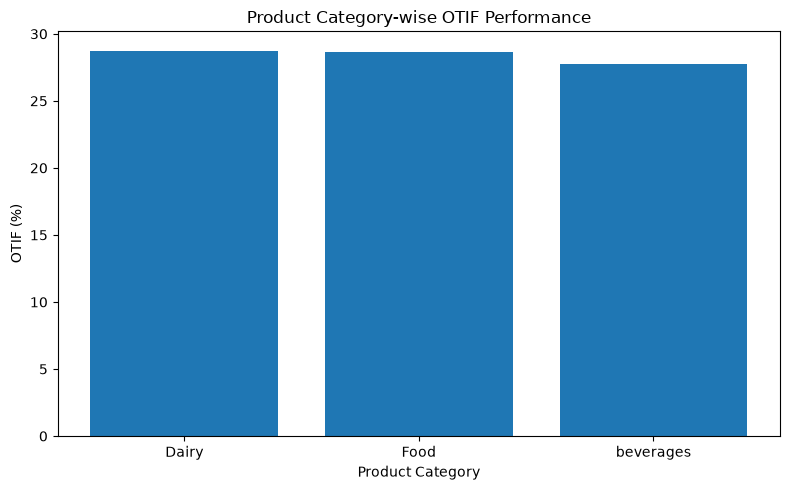

In [14]:
plt.figure(figsize=(8,5))

plt.bar(
    category_performance["category"],
    category_performance["otif"]
)

plt.title("Product Category-wise OTIF Performance")

plt.xlabel("Product Category")

plt.ylabel("OTIF (%)")

plt.tight_layout()

plt.show()

## Business Insights

### Key Findings

- **Dairy** achieved the highest OTIF performance (**28.75%**) among all product categories. Although it performs slightly better than the others, the OTIF value remains low, indicating opportunities to improve delivery reliability.

- **Food** recorded the highest On-Time Delivery rate (**70.16%**), suggesting effective transportation and scheduling. However, its lower In-Full Delivery rate (**45.07%**) reduced its overall OTIF performance.

- **Beverages** had the lowest OTIF performance (**27.77%**), indicating that this category experiences the greatest challenges in fulfilling customer orders on time and in full.

- Across all product categories, **In-Full Delivery rates are below 50%**, while On-Time Delivery rates exceed 60%. This suggests that the primary challenge lies in fulfilling complete order quantities rather than delivering orders on schedule.

### Conclusion

The analysis indicates that improving inventory availability, warehouse picking accuracy, and replenishment planning can significantly increase In-Full Delivery performance. Since OTIF depends on both timely and complete deliveries, focusing on order fulfillment processes will have the greatest impact on overall customer service levels.

"The Dairy category achieved the highest OTIF performance at 28.75%, while Beverages recorded the lowest at 27.77%. Although the On-Time Delivery rate exceeded 60% across all categories, the In-Full Delivery rate remained below 50%. This indicates that the major operational challenge is fulfilling complete customer orders rather than delivering them on time. Improving inventory planning and warehouse operations would help increase OTIF across all product categories

# Business Question 5: Monthly Delivery Performance Trend

This analysis evaluates monthly delivery performance using three key supply chain metrics:

- On-Time Delivery (OT)
- In-Full Delivery (IF)
- On-Time In-Full (OTIF)

Monitoring these KPIs over time helps identify trends, evaluate operational consistency, and detect periods where delivery performance requires improvement.

The insights can support better planning, resource allocation, and continuous improvement initiatives.

In [15]:
## Calculate monthly performance metrics for on-time, in-full, and OTIF
monthly_performance = (
    orders
    .groupby(["Month_Number", "Month"])[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

monthly_performance["on_time"] *= 100
monthly_performance["in_full"] *= 100
monthly_performance["otif"] *= 100

monthly_performance = monthly_performance.round(2)

monthly_performance = monthly_performance.sort_values("Month_Number")

monthly_performance

,Month_Number,Month,on_time,in_full,otif
0,3,March,71.45,43.34,28.17
1,4,April,71.39,43.63,28.12
2,5,May,70.40,43.63,27.63


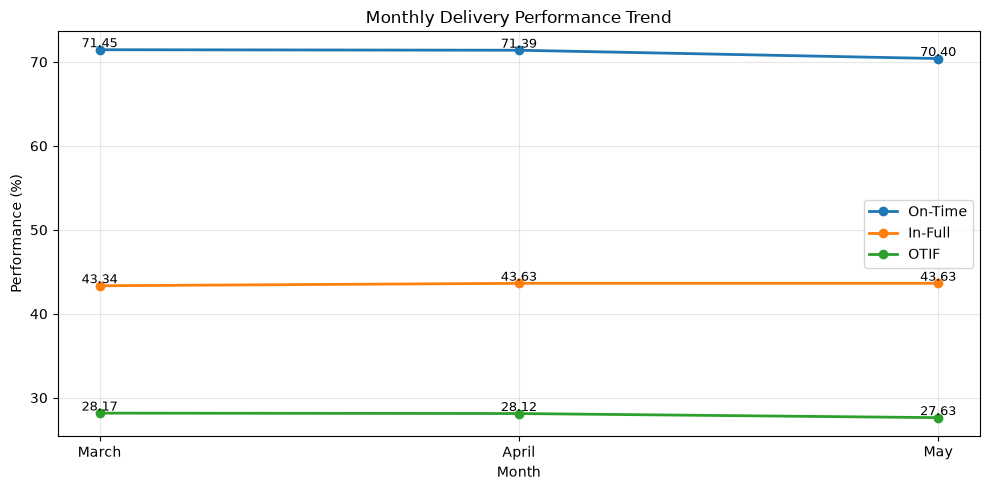

In [16]:
plt.figure(figsize=(10,5))

plt.plot(monthly_performance["Month"], monthly_performance["on_time"],
         marker="o", linewidth=2, label="On-Time")

plt.plot(monthly_performance["Month"], monthly_performance["in_full"],
         marker="o", linewidth=2, label="In-Full")

plt.plot(monthly_performance["Month"], monthly_performance["otif"],
         marker="o", linewidth=2, label="OTIF")

# Display values on each point
for col in ["on_time", "in_full", "otif"]:
    for x, y in zip(monthly_performance["Month"], monthly_performance[col]):
        plt.text(x, y + 0.3, f"{y:.2f}", ha="center", fontsize=9)

plt.title("Monthly Delivery Performance Trend")
plt.xlabel("Month")
plt.ylabel("Performance (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [17]:
## find the best and worst performing months based on OTIF
best_month = monthly_performance.loc[
    monthly_performance["otif"].idxmax()
]

worst_month = monthly_performance.loc[
    monthly_performance["otif"].idxmin()
]

print("Best Month")
print(best_month)

print("\nWorst Month")
print(worst_month)

Best Month
Month_Number        3
Month           March
on_time         71.45
in_full         43.34
otif            28.17
Name: 0, dtype: object

Worst Month
Month_Number        5
Month             May
on_time          70.4
in_full         43.63
otif            27.63
Name: 2, dtype: object


## Business Insights

### Key Findings

- March achieved the highest OTIF performance (28.17%), while May recorded the lowest (27.63%).
- On-Time Delivery showed a slight downward trend from 71.45% in March to 70.40% in May.
- In-Full Delivery remained stable at approximately 43.6%, indicating consistent inventory fulfillment performance.
- OTIF stayed below 30% across all three months, showing that many orders failed to meet both timeliness and completeness requirements simultaneously.
- The small month-to-month variation suggests persistent operational inefficiencies rather than isolated incidents.

### Conclusion

The monthly trend indicates consistent operational performance with only minor fluctuations. Although no significant disruptions occurred, the low OTIF values highlight opportunities to improve inventory planning, warehouse operations, and transportation coordination to achieve better customer service levels.

At the end, I analyzed monthly On-Time, In-Full, and OTIF performance from March to May. The results showed stable operational performance with only minor fluctuations. March recorded the highest OTIF at 28.17%, while May had the lowest at 27.63%. Since OTIF remained below 30% in every month, I concluded that the company faces ongoing operational challenges rather than a one-time issue. This suggests improvements are needed in inventory management, warehouse execution, and delivery planning

# Business Question 6: Top & Bottom Performing Customers

This analysis evaluates customer-level delivery performance using OTIF (On-Time In-Full).

The objective is to identify:

- Top-performing customers with the highest OTIF.
- Bottom-performing customers with the lowest OTIF.
- Opportunities to improve service quality for customers experiencing poor delivery performance.

These insights help management prioritize operational improvements and strengthen customer relationships.

In [18]:
customer_performance = (
    orders
    .groupby("customer_name")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

customer_performance["on_time"] *= 100
customer_performance["in_full"] *= 100
customer_performance["otif"] *= 100

customer_performance = customer_performance.round(2)

customer_performance.head()

,customer_name,on_time,in_full,otif
0,Acclaimed Stores,25.63,61.49,15.54
1,Atlas Stores,82.24,47.74,36.10
2,Best Market,84.47,47.20,37.27
3,Chiptec Stores,84.59,50.73,38.95
4,Colonial Farms,81.79,54.05,40.90


In [19]:
top_customers = (
    customer_performance
    .sort_values("otif", ascending=False)
    .head(10)
)

top_customers

,customer_name,on_time,in_full,otif
9,Expression Stores,84.73,57.34,45.66
17,Propel Mart,86.92,51.58,42.47
12,Info Stores,82.78,54.64,42.07
19,ShopRite,85.90,51.25,40.97
4,Colonial Farms,81.79,54.05,40.90
14,Logic Stores,83.43,51.49,39.55
3,Chiptec Stores,84.59,50.73,38.95
22,Viveks Stores,81.72,50.69,37.53
2,Best Market,84.47,47.20,37.27
6,Costco Wholesale,83.57,48.46,37.22


In [20]:
bottom_customers = (
    customer_performance
    .sort_values("otif")
    .head(10)
)

bottom_customers

,customer_name,on_time,in_full,otif
10,Fairway Market,28.53,17.12,4.20
16,Price Rite,83.67,11.27,6.50
15,Lotus Mart,26.28,41.97,11.18
5,Coolblue,27.81,39.24,12.22
0,Acclaimed Stores,25.63,61.49,15.54
13,Lidl,24.44,62.15,18.22
21,Vijay Stores,84.72,27.36,19.10
7,Elite Mart,85.62,28.04,21.49
20,Sorefoz Mart,84.61,29.38,22.02
11,Foodtown,81.98,38.89,24.66


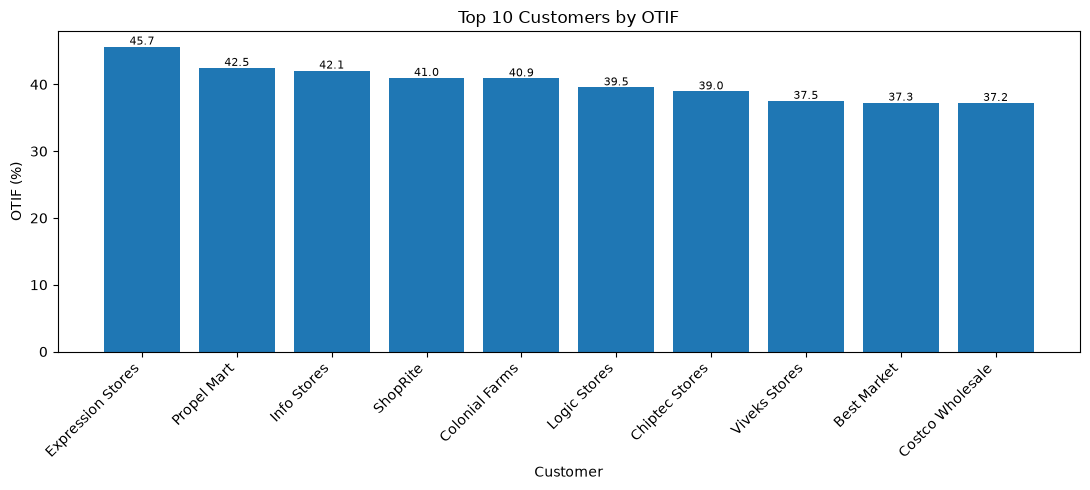

In [21]:
plt.figure(figsize=(11,5))

bars = plt.bar(
    top_customers["customer_name"],
    top_customers["otif"]
)

plt.title("Top 10 Customers by OTIF")
plt.xlabel("Customer")
plt.ylabel("OTIF (%)")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

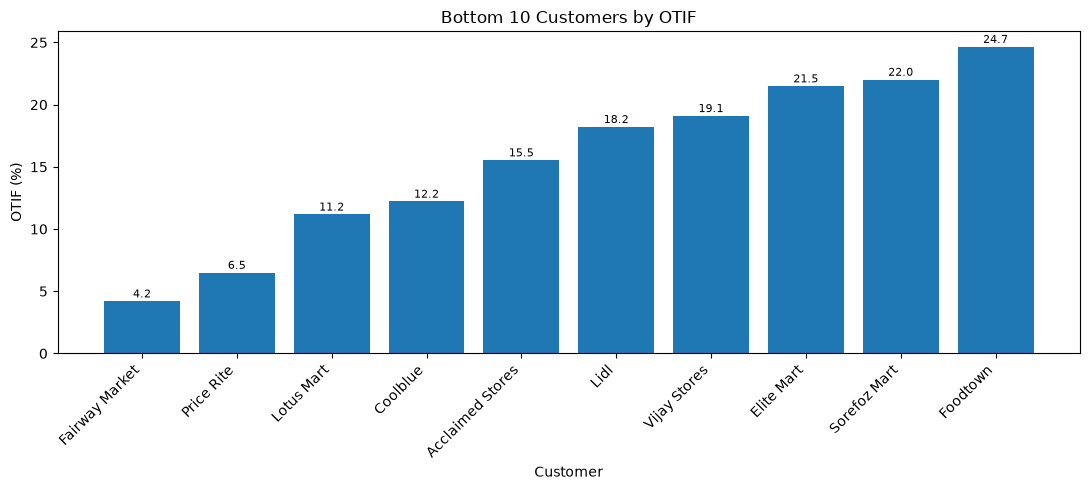

In [22]:
plt.figure(figsize=(11,5))

bars = plt.bar(
    bottom_customers["customer_name"],
    bottom_customers["otif"]
)

plt.title("Bottom 10 Customers by OTIF")
plt.xlabel("Customer")
plt.ylabel("OTIF (%)")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [23]:
comparison = {
    "Top 10 Average OTIF": round(top_customers["otif"].mean(), 2),
    "Bottom 10 Average OTIF": round(bottom_customers["otif"].mean(), 2)
}

comparison

{'Top 10 Average OTIF': np.float64(40.26),
 'Bottom 10 Average OTIF': np.float64(15.51)}

## Business Insights

### Key Findings

- **Expression Stores** achieved the highest OTIF performance (**45.66%**), making it the best-performing customer. It also maintained strong On-Time (84.73%) and In-Full (57.34%) delivery performance.
- The **Top 10 customers** recorded an average OTIF of **40.26%**, which is significantly higher than the company average of **28.71%**.
- **Fairway Market** had the lowest OTIF (**4.20%**) due to poor On-Time (28.53%) and In-Full (17.12%) performance, indicating major supply chain execution issues.
- The **Bottom 10 customers** achieved an average OTIF of only **15.51%**, highlighting severe service quality challenges.
- There is a **24.75 percentage point gap** between the Top 10 and Bottom 10 customers (40.26% vs. 15.51%), demonstrating inconsistent delivery performance across the customer base.

### Customer-Specific Observations

- **Acclaimed Stores** and **Lidl** have relatively high In-Full performance (above 60%) but very low On-Time performance (below 30%). This suggests inventory is available, but deliveries are reaching customers late.
- **Price Rite** and **Vijay Stores** achieved high On-Time performance (above 80%) but very low In-Full performance (below 30%), indicating transportation is efficient but inventory availability or warehouse fulfillment is weak.
- The top-performing customers consistently maintain both strong On-Time and In-Full delivery, resulting in higher OTIF scores.

### Business Recommendations

- Conduct root cause analysis for customers with OTIF below 20%, starting with **Fairway Market**, **Price Rite**, and **Lotus Mart**.
- Improve transportation planning for customers with low On-Time performance despite good In-Full rates.
- Strengthen inventory planning and warehouse operations for customers with high On-Time but poor In-Full performance.
- Study the operational practices used for **Expression Stores** and other top-performing customers and apply those best practices to lower-performing customers.
- Continuously monitor customer-level KPIs through dashboards to detect declining performance early.

### Conclusion

Customer-level analysis reveals substantial variation in delivery performance. While several customers receive reliable service, others experience frequent delays or incomplete deliveries. Targeted operational improvements based on the specific issue—whether transportation or inventory fulfillment—can improve OTIF, enhance customer satisfaction, and create a more consistent supply chain.

# Business Question 7: Root Cause Analysis

This analysis investigates the operational factors contributing to low OTIF (On-Time In-Full) performance.

Rather than only measuring KPIs, the objective is to identify the root causes behind poor delivery performance.

The insights will help management prioritize operational improvements in inventory planning, warehouse operations, transportation, and customer service.

In [24]:
## Analysis 1: Which KPI is the Biggest Bottleneck?
kpi_summary = pd.DataFrame({
    "KPI": ["On-Time", "In-Full", "OTIF"],
    "Performance (%)": [
        orders["on_time"].mean() * 100,
        orders["in_full"].mean() * 100,
        orders["otif"].mean() * 100
    ]
})

kpi_summary = kpi_summary.round(2)

kpi_summary

,KPI,Performance (%)
0,On-Time,71.21
1,In-Full,43.51
2,OTIF,28.04


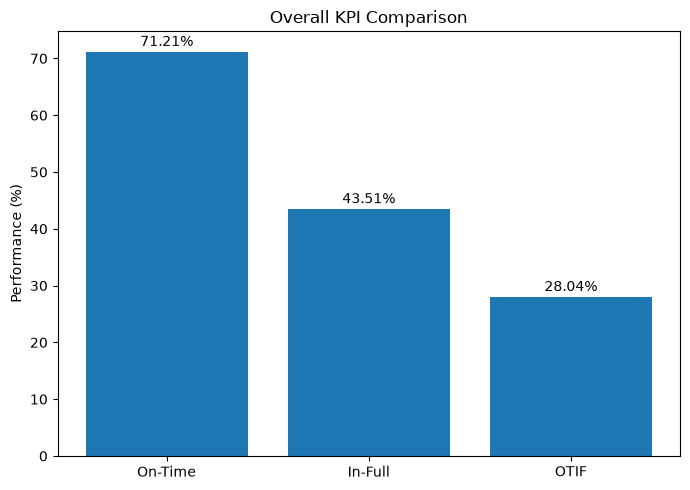

In [25]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    kpi_summary["KPI"],
    kpi_summary["Performance (%)"]
)

plt.title("Overall KPI Comparison")

plt.ylabel("Performance (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+1,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()

## Business Insights

### Root Cause 1: Low OTIF Performance

#### Key Findings

- **On-Time Delivery (71.21%)** is the strongest operational KPI, indicating that most orders are dispatched and delivered within the committed delivery schedule.
- **In-Full Delivery (43.51%)** is substantially lower than On-Time Delivery, suggesting that a significant number of orders are delivered with missing or incomplete quantities.
- **OTIF (28.04%)** is the lowest KPI because an order is considered successful only when it is delivered **both on time and in full**.
- The gap of **27.70 percentage points** between On-Time and In-Full performance indicates that inventory availability and order fulfillment are the primary constraints affecting OTIF.
- Although transportation performance appears relatively strong, inventory shortages, warehouse picking errors, or replenishment delays are preventing the company from achieving higher OTIF performance.

#### Business Conclusion

The analysis indicates that **In-Full Delivery is the primary operational bottleneck** rather than transportation. Improving inventory planning, warehouse operations, and order fulfillment processes is likely to have the greatest positive impact on overall OTIF performance.
At last conclude that OTIF requires both conditions to be met simultaneously—orders must be delivered on time and in full. While the company performs relatively well in terms of delivery timing, with an On-Time rate of 71.21%, the In-Full rate is only 43.51%. This means many orders reach customers on schedule but with incomplete quantities. As a result, OTIF drops to 28.04%. Therefore, the main operational issue appears to be inventory availability and warehouse fulfillment rather than transportation.

In [26]:
actual_performance = (
    orders
    .groupby("customer_name")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

actual_performance["on_time"] *= 100
actual_performance["in_full"] *= 100
actual_performance["otif"] *= 100

actual_performance = actual_performance.rename(columns={
    "on_time": "Actual OT",
    "in_full": "Actual IF",
    "otif": "Actual OTIF"
})

target_performance = (
    orders
    .groupby("customer_name")[["ontime_target%", "infull_target%", "otif_target%"]]
    .mean()
    .reset_index()
)

target_performance = target_performance.rename(columns={
    "ontime_target%": "Target OT",
    "infull_target%": "Target IF",
    "otif_target%": "Target OTIF"
})

customer_kpi = actual_performance.merge(
    target_performance,
    on="customer_name"
)

customer_kpi["OT Gap"] = customer_kpi["Actual OT"] - customer_kpi["Target OT"]
customer_kpi["IF Gap"] = customer_kpi["Actual IF"] - customer_kpi["Target IF"]
customer_kpi["OTIF Gap"] = customer_kpi["Actual OTIF"] - customer_kpi["Target OTIF"]

customer_kpi = customer_kpi.round(2)

customer_kpi.head()

,customer_name,Actual OT,Actual IF,Actual OTIF,Target OT,Target IF,Target OTIF,OT Gap,IF Gap,OTIF Gap
0,Acclaimed Stores,25.63,61.49,15.54,77.03,79.0,61.03,-51.40,-17.51,-45.49
1,Atlas Stores,82.24,47.74,36.10,85.00,80.0,68.00,-2.76,-32.26,-31.90
2,Best Market,84.47,47.20,37.27,92.00,80.0,74.00,-7.53,-32.80,-36.73
3,Chiptec Stores,84.59,50.73,38.95,87.00,81.0,70.00,-2.41,-30.27,-31.05
4,Colonial Farms,81.79,54.05,40.90,86.00,77.0,66.00,-4.21,-22.95,-25.10


In [27]:
worst_gap = (
    customer_kpi
    .sort_values("OTIF Gap")
    .head(5)
)

worst_gap

,customer_name,Actual OT,Actual IF,Actual OTIF,Target OT,Target IF,Target OTIF,OT Gap,IF Gap,OTIF Gap
16,Price Rite,83.67,11.27,6.50,92.00,67.00,62.00,-8.33,-55.73,-55.50
21,Vijay Stores,84.72,27.36,19.10,90.98,74.15,67.61,-6.26,-46.78,-48.52
10,Fairway Market,28.53,17.12,4.20,75.00,68.00,51.00,-46.47,-50.88,-46.80
15,Lotus Mart,26.28,41.97,11.18,78.50,73.54,57.53,-52.23,-31.57,-46.36
0,Acclaimed Stores,25.63,61.49,15.54,77.03,79.00,61.03,-51.40,-17.51,-45.49


In [28]:
customer_issue = customer_performance.copy()

customer_issue["Primary Issue"] = customer_issue.apply(
    lambda row:
    "Transportation"
    if row["on_time"] < row["in_full"]
    else "Inventory/Warehouse",
    axis=1
)

issue_summary = (
    customer_issue["Primary Issue"]
    .value_counts()
    .reset_index()
)

issue_summary.columns = [
    "Issue",
    "Number of Customers"
]

issue_summary

,Issue,Number of Customers
0,Inventory/Warehouse,21
1,Transportation,4


## Business Insights

### Root Cause 2: Customers with the Largest OTIF Gap

#### Key Findings

- **Price Rite** recorded the largest OTIF gap (**-55.50 percentage points**), with an Actual OTIF of only **6.50%** against a target of **62.00%**. The major contributor is its very low **In-Full Delivery (11.27%)**, indicating significant inventory or warehouse fulfillment issues.
- **Vijay Stores** achieved a high **On-Time Delivery (84.72%)**, but its **In-Full Delivery was only 27.36%**, resulting in an OTIF gap of **-48.52 percentage points**. This suggests transportation is performing well, while inventory availability is the primary concern.
- **Fairway Market** experienced poor performance in both **On-Time (28.53%)** and **In-Full (17.12%)** delivery, leading to an OTIF of just **4.20%**. This indicates combined transportation and warehouse execution problems.
- **Lotus Mart** and **Acclaimed Stores** showed relatively better In-Full performance than On-Time Delivery. Their largest performance gap is due to delayed deliveries, suggesting transportation and route planning issues.
- None of the five customers met their agreed OTIF targets, indicating that service-level expectations are consistently being missed for these key accounts.

### Business Recommendations

- Prioritize **Price Rite** and **Vijay Stores** by improving inventory planning, replenishment, and warehouse picking processes.
- Conduct transportation route optimization and delivery scheduling reviews for **Fairway Market**, **Lotus Mart**, and **Acclaimed Stores** to improve On-Time Delivery.
- Implement customer-specific performance monitoring for accounts with OTIF gaps greater than **40 percentage points**.
- Perform detailed root cause investigations with warehouse, logistics, and inventory teams to identify recurring operational bottlenecks.
- Review customer demand forecasting and safety stock policies for customers experiencing frequent In-Full delivery failures.

### Conclusion

The analysis shows that poor OTIF performance is driven by different operational issues for different customers. While some customers primarily suffer from inventory shortages, others experience transportation delays. A customer-specific improvement strategy, rather than a single company-wide solution, is required to improve overall service levels.

"I compared each customer's actual delivery performance with their agreed service-level targets and calculated OTIF gaps. I then identified the five customers with the largest negative gaps. The analysis revealed that the reasons for poor OTIF differed by customer. For example, Price Rite had severe inventory fulfillment issues because its In-Full Delivery was only 11.27%, while Fairway Market struggled with both On-Time and In-Full performance. This showed that operational improvements should be customer-specific rather than applying the same solution across all customers

city_performance = (
    orders
    .groupby("city")[["on_time","in_full","otif"]]
    .mean()
    .reset_index()
)

city_performance[["on_time","in_full","otif"]] *= 100

city_performance = city_performance.round(2)

city_performance.sort_values("otif")

In [29]:
### Root Cause 3: City-wise Delivery Performance
city_performance = (
    orders
    .groupby("city")[["on_time","in_full","otif"]]
    .mean()
    .reset_index()
)

city_performance[["on_time","in_full","otif"]] *= 100

city_performance = city_performance.round(2)

city_performance.sort_values("otif")

,city,on_time,in_full,otif
2,Vadodara,69.91,43.18,27.29
0,Ahmedabad,70.40,44.53,28.24
1,"New Jersey, US",73.49,42.76,28.62


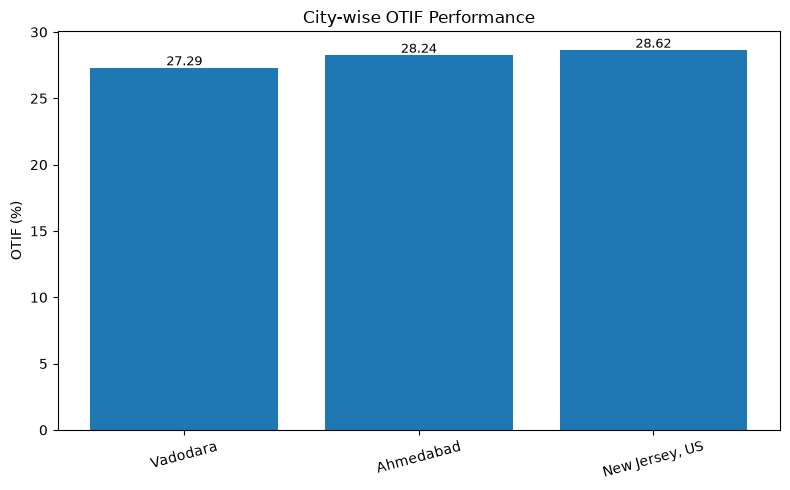

In [30]:
city_chart = city_performance.sort_values("otif")

plt.figure(figsize=(8,5))

bars = plt.bar(
    city_chart["city"],
    city_chart["otif"]
)

plt.title("City-wise OTIF Performance")

plt.ylabel("OTIF (%)")

plt.xticks(rotation=15)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.2,
        f"{h:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## Business Insights

### Root Cause 3: City-wise Delivery Performance

#### Key Findings

- **New Jersey, US** achieved the highest OTIF performance (**28.62%**) and the highest On-Time Delivery (**73.49%**), indicating relatively better transportation efficiency.
- **Vadodara** recorded the lowest OTIF (**27.29%**) and the lowest On-Time Delivery (**69.91%**), suggesting transportation and delivery scheduling require improvement.
- **Ahmedabad** performed slightly better than Vadodara with an OTIF of **28.24%**, mainly due to its stronger In-Full Delivery (**44.53%**).
- The OTIF difference between the best and worst-performing cities is only **1.33 percentage points**, indicating that delivery performance is consistently low across all locations rather than being isolated to a single city.
- All three cities recorded OTIF values below **30%**, indicating company-wide operational challenges.

#### Business Recommendations

- Investigate transportation delays and route planning in Vadodara.
- Adopt best transportation practices from the New Jersey operations where applicable.
- Improve inventory availability across all warehouses, as In-Full Delivery remains below 45% in every city.
- Monitor city-level KPIs monthly to identify regional performance trends.

I grouped the data by city and calculated On-Time, In-Full, and OTIF performance. New Jersey achieved the highest OTIF at 28.62%, while Vadodara had the lowest at 27.29%. However, the performance difference across cities was only 1.33 percentage points, which suggests that low OTIF is a company-wide issue rather than a problem limited to one region. This indicates that improvements should focus on organization-wide inventory and fulfillment processes instead of targeting a single city."

In [31]:
## Root Cause Analysis 4 – Product Category
category_performance = (
    orders
    .groupby("category")[["on_time", "in_full", "otif"]]
    .mean()
    .reset_index()
)

category_performance[["on_time", "in_full", "otif"]] *= 100

category_performance = category_performance.round(2)

category_performance.sort_values("otif")

,category,on_time,in_full,otif
2,beverages,71.82,43.10,27.53
0,Dairy,70.86,43.65,28.13
1,Food,71.99,43.39,28.18


## Business Insights

### Root Cause 4: Product Category Performance

#### Key Findings

- **Food** achieved the highest OTIF performance (**28.18%**) and the highest On-Time Delivery (**71.99%**), indicating relatively better delivery execution.
- **Beverages** recorded the lowest OTIF (**27.53%**) due to the lowest In-Full Delivery (**43.10%**), suggesting inventory or warehouse fulfillment challenges.
- **Dairy** showed the highest In-Full Delivery (**43.65%**), but slightly lower On-Time Delivery compared to the other categories.
- The difference between the highest and lowest OTIF is only **0.65 percentage points**, indicating that all product categories experience similar operational performance.
- All categories have **In-Full Delivery below 45%**, confirming that inventory availability and warehouse execution are common issues across the product portfolio.

#### Business Recommendations

- Improve inventory forecasting and replenishment planning for all product categories.
- Review warehouse picking and packing processes to reduce incomplete deliveries.
- Increase safety stock for frequently out-of-stock products.
- Monitor category-wise OTIF trends regularly to detect future performance changes.

I grouped orders by product category and calculated On-Time, In-Full, and OTIF performance. Food had the highest OTIF at 28.18%, while Beverages had the lowest at 27.53%. However, the difference was only 0.65 percentage points. This indicates that low OTIF is not driven by a single product category but is a company-wide operational issue. Additionally, every category had an In-Full Delivery rate below 45%, suggesting that inventory management and warehouse fulfillment are the primary areas requiring improvement.


In [32]:
##  Final Root Cause
customer_issue = customer_performance.copy()

customer_issue["Primary Issue"] = customer_issue.apply(
    lambda row:
        "Transportation"
        if row["on_time"] < row["in_full"]
        else "Inventory/Warehouse",
    axis=1
)

customer_issue[["customer_name", "on_time", "in_full", "Primary Issue"]].head()

,customer_name,on_time,in_full,Primary Issue
0,Acclaimed Stores,25.63,61.49,Transportation
1,Atlas Stores,82.24,47.74,Inventory/Warehouse
2,Best Market,84.47,47.20,Inventory/Warehouse
3,Chiptec Stores,84.59,50.73,Inventory/Warehouse
4,Colonial Farms,81.79,54.05,Inventory/Warehouse


In [33]:
issue_summary = (
    customer_issue["Primary Issue"]
    .value_counts()
    .reset_index()
)

issue_summary.columns = ["Issue", "Number of Customers"]

issue_summary

,Issue,Number of Customers
0,Inventory/Warehouse,21
1,Transportation,4


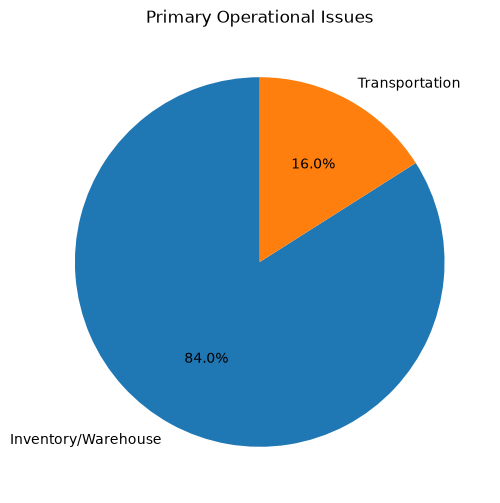

In [34]:
plt.figure(figsize=(6,6))

plt.pie(
    issue_summary["Number of Customers"],
    labels=issue_summary["Issue"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Primary Operational Issues")

plt.show()

## Business Insights

### Root Cause 5: Primary Operational Issue Classification

#### Key Findings

- Out of **25 customers**, **21 customers (84%)** were primarily affected by **Inventory/Warehouse issues**.
- Only **4 customers (16%)** experienced Transportation as their main operational challenge.
- This confirms that inventory availability and warehouse fulfillment have a much greater impact on delivery performance than transportation.
- The findings are consistent with the overall KPI analysis, where On-Time Delivery (71.21%) was significantly higher than In-Full Delivery (43.51%).
- Improving warehouse operations and inventory management is expected to have the greatest positive impact on overall OTIF performance.

#### Business Recommendations

- Improve demand forecasting and inventory replenishment planning.
- Increase warehouse picking and packing accuracy.
- Review safety stock levels for high-demand products.
- Implement real-time inventory monitoring to reduce stock shortages.
- Continue monitoring transportation performance for the few customers experiencing delivery delays.

"I classified each customer based on whether their weaker KPI was On-Time Delivery or In-Full Delivery. The analysis showed that 21 out of 25 customers, or 84%, were primarily affected by inventory and warehouse issues, while only 4 customers faced transportation-related problems. This aligns with the KPI analysis, where On-Time Delivery was 71.21% but In-Full Delivery was only 43.51%. Therefore, improving inventory planning and warehouse execution would likely have the greatest impact on increasing OTIF."